In [1]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
df_01 = pd.read_csv('data/2025-01.csv')
df_02 = pd.read_csv('data/2025-02.csv')
df_03 = pd.read_csv('data/2025-03.csv')
df_q1 = pd.concat([df_01, df_02, df_03], ignore_index = True)

In [3]:
df_q1.shape

(5387982, 9)

In [4]:
df_q1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5387982 entries, 0 to 5387981
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Genero_Usuario         object 
 1   Edad_Usuario           float64
 2   Bici                   int64  
 3   Ciclo_Estacion_Retiro  object 
 4   Fecha_Retiro           object 
 5   Hora_Retiro            object 
 6   Ciclo_EstacionArribo   object 
 7   Fecha_Arribo           object 
 8   Hora_Arribo            object 
dtypes: float64(1), int64(1), object(7)
memory usage: 370.0+ MB


In [6]:
# Crear una nueva columna con fecha y hora
df_q1['FechaHora_Arribo'] = pd.to_datetime(df_q1['Fecha_Arribo'].astype(str) + ' ' + df_q1['Hora_Arribo'].astype(str), dayfirst=True)
df_q1['FechaHora_Retiro'] = pd.to_datetime(df_q1['Fecha_Retiro'].astype(str) + ' ' + df_q1['Hora_Retiro'].astype(str), dayfirst=True)

# Convertir a fechas
df_q1['Fecha_Retiro'] = pd.to_datetime(df_q1['Fecha_Retiro'],format='%d/%m/%Y')
df_q1['Fecha_Arribo'] = pd.to_datetime(df_q1['Fecha_Arribo'],format='%d/%m/%Y')

In [7]:
# Obtener nombre de Día de Retiro
df_q1['Dia_Retiro'] = df_q1['Fecha_Retiro'].dt.day_name()
df_q1['Dia_Arribo'] = df_q1['Fecha_Arribo'].dt.day_name()

# Columna de hora 
df_q1['HoraCorta_Arribo'] = df_q1['FechaHora_Arribo'].dt.hour
df_q1['HoraCorta_Retiro'] = df_q1['FechaHora_Retiro'].dt.hour

In [22]:
df_q1['Duracion_Viaje'] = ((df_q1['FechaHora_Arribo'] - df_q1['FechaHora_Retiro']).dt.total_seconds() / 60).round(2)

In [23]:
df_q1.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,FechaHora_Arribo,FechaHora_Retiro,Dia_Retiro,Dia_Arribo,HoraCorta_Arribo,HoraCorta_Retiro,Duracion_Viaje
0,M,26.0,5180930,568,2024-12-31,23:57:02,572,2025-01-01,00:00:03,2025-01-01 00:00:03,2024-12-31 23:57:02,Tuesday,Wednesday,0,23,3.02
1,F,54.0,3653953,283,2024-12-31,23:51:40,596,2025-01-01,00:00:41,2025-01-01 00:00:41,2024-12-31 23:51:40,Tuesday,Wednesday,0,23,9.02
2,M,38.0,7511322,034,2024-12-31,23:48:36,064,2025-01-01,00:00:59,2025-01-01 00:00:59,2024-12-31 23:48:36,Tuesday,Wednesday,0,23,12.38
3,M,41.0,3804572,258,2024-12-31,23:54:11,023,2025-01-01,00:01:08,2025-01-01 00:01:08,2024-12-31 23:54:11,Tuesday,Wednesday,0,23,6.95
4,M,35.0,3848405,043,2024-12-31,23:35:28,126,2025-01-01,00:01:17,2025-01-01 00:01:17,2024-12-31 23:35:28,Tuesday,Wednesday,0,23,25.82


In [9]:
df_q1.isnull().sum()

Genero_Usuario             3
Edad_Usuario             343
Bici                       0
Ciclo_Estacion_Retiro      0
Fecha_Retiro               0
Hora_Retiro                0
Ciclo_EstacionArribo       0
Fecha_Arribo               0
Hora_Arribo                0
FechaHora_Arribo           0
FechaHora_Retiro           0
Dia_Retiro                 0
Dia_Arribo                 0
HoraCorta_Arribo           0
HoraCorta_Retiro           0
dtype: int64

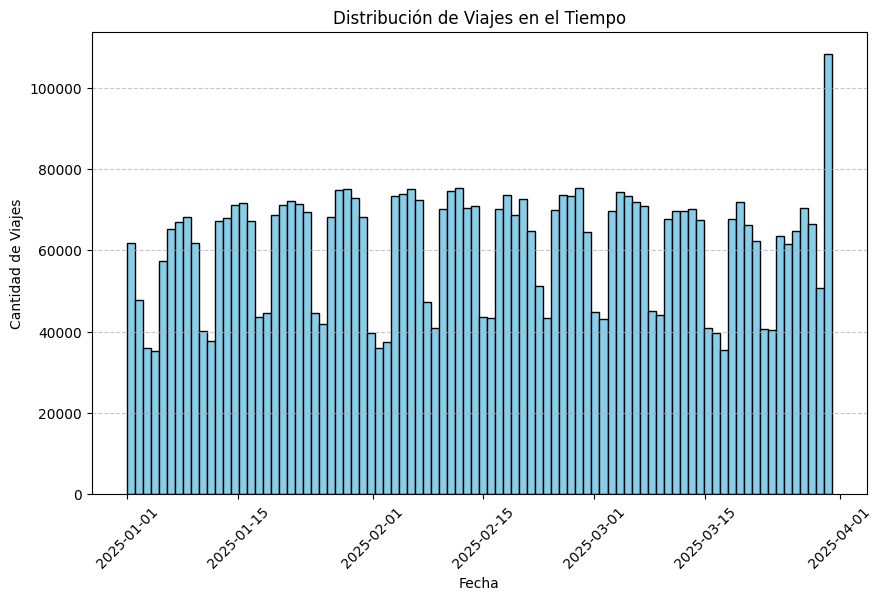

In [30]:
# Configuramos el tamaño de la imagen
plt.figure(figsize=(10, 6))

# Creamos el histograma
# 'bins' define cuántas barras quieres ver (ej. 30 barras para un mes)
plt.hist(df_q1['Fecha_Arribo'], bins=88, color='skyblue', edgecolor='black')

plt.title('Distribución de Viajes en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=45) # Rotamos las fechas para que se lean bien
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [36]:
import numpy as np
bins = [0, 3, 10, 20, 30, 40, np.inf]
labels = ['0-3 min', '3-10 min', '10-20 min', '20-30 min', '30-40 min', '>40 min']

# Creamos la nueva columna categorizada
df_q1['Rango_duracion'] = pd.cut(df_q1['Duracion_Viaje'], bins=bins, labels=labels)

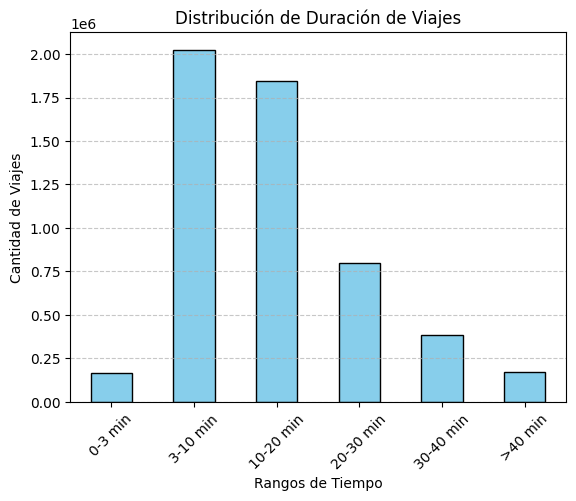

In [37]:
df_q1['Rango_duracion'].value_counts(sort=False).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribución de Duración de Viajes')
plt.xlabel('Rangos de Tiempo')
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Wednesday'),
  Text(1, 0, 'Thursday'),
  Text(2, 0, 'Friday'),
  Text(3, 0, 'Saturday'),
  Text(4, 0, 'Sunday'),
  Text(5, 0, 'Monday'),
  Text(6, 0, 'Tuesday')])

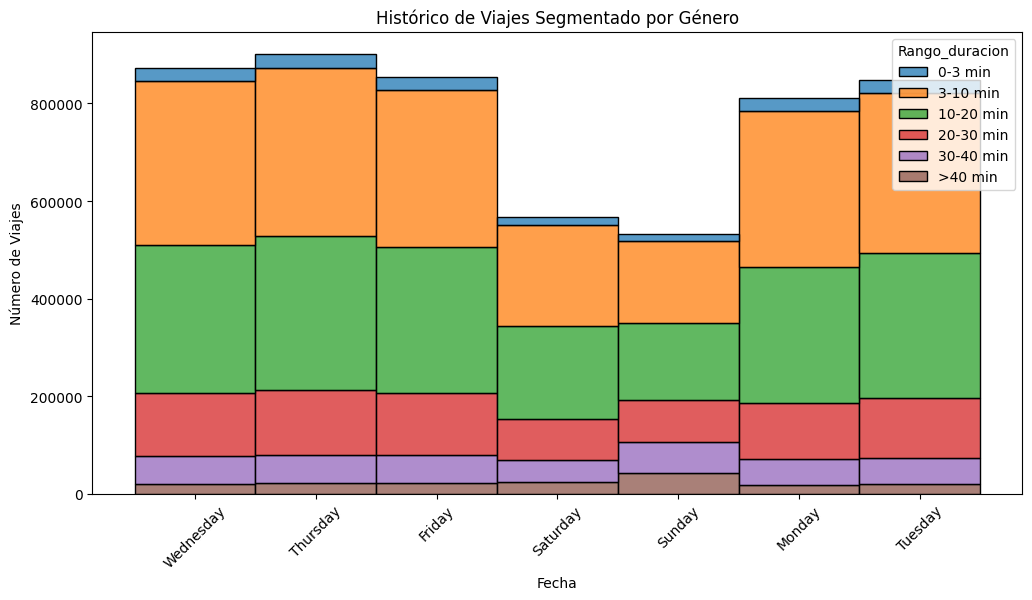

In [44]:
import seaborn as sns

plt.figure(figsize=(12, 6))

# 'hue' divide las barras por la columna de género
sns.histplot(data=df_q1, x='Dia_Arribo', hue='Rango_duracion', multiple='stack', bins=40)

plt.title('Histórico de Viajes Segmentado por Género')
plt.xlabel('Fecha')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=45)

<Axes: xlabel='Rango_duracion'>

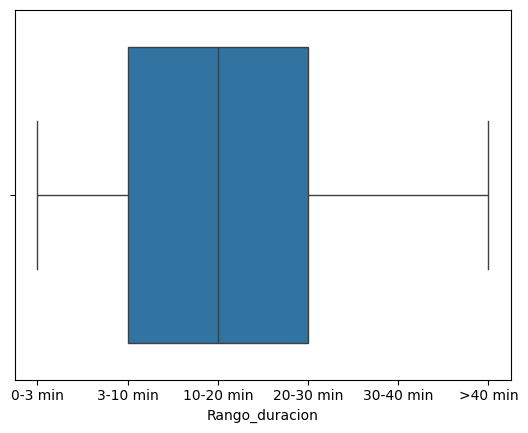

In [39]:
import seaborn as sns
sns.boxplot(x=df_q1["Rango_duracion"])

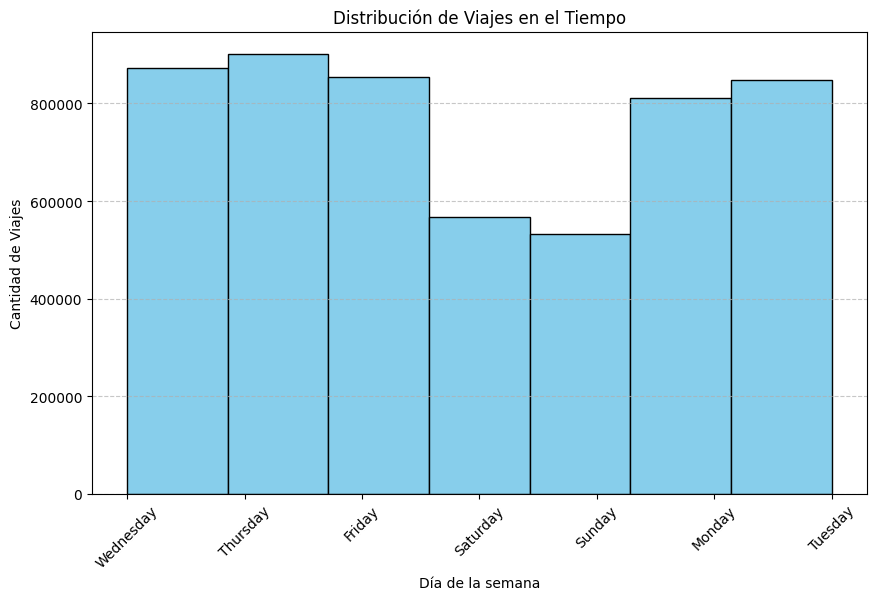

In [10]:
plt.figure(figsize=(10, 6))

# Creamos el histograma
# 'bins' define cuántas barras quieres ver (ej. 30 barras para un mes)
plt.hist(df_q1['Dia_Arribo'], bins=7, color='skyblue', edgecolor='black')

plt.title('Distribución de Viajes en el Tiempo')
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=45) # Rotamos las fechas para que se lean bien
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Wednesday'),
  Text(1, 0, 'Thursday'),
  Text(2, 0, 'Friday'),
  Text(3, 0, 'Saturday'),
  Text(4, 0, 'Sunday'),
  Text(5, 0, 'Monday'),
  Text(6, 0, 'Tuesday')])

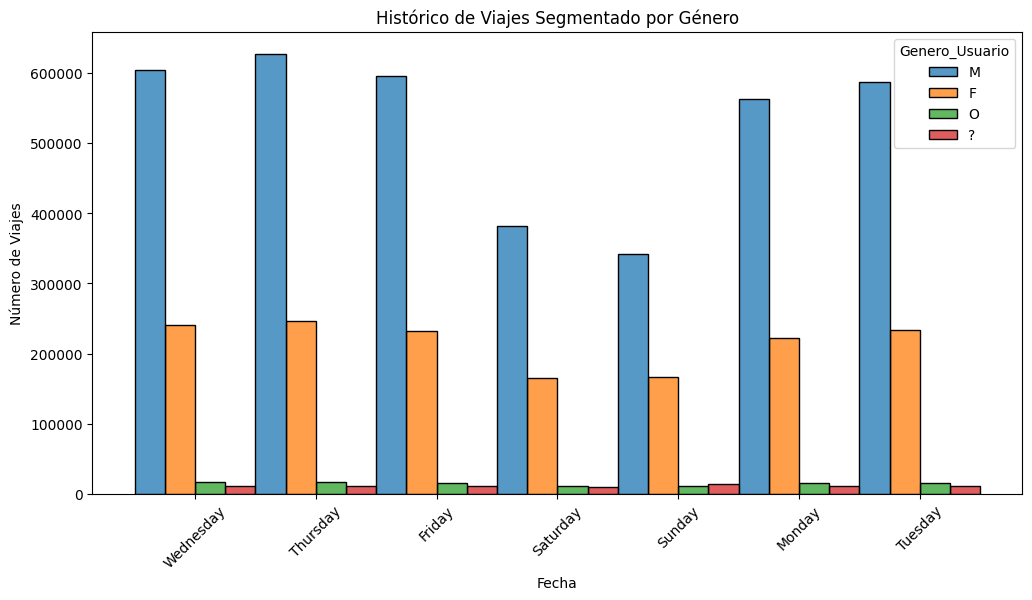

In [11]:
import seaborn as sns

plt.figure(figsize=(12, 6))

# 'hue' divide las barras por la columna de género
sns.histplot(data=df_q1, x='Dia_Arribo', hue='Genero_Usuario', multiple='dodge', bins=40)

plt.title('Histórico de Viajes Segmentado por Género')
plt.xlabel('Fecha')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=45)

In [49]:
top_10_arribo = df_q1['Ciclo_EstacionArribo'].value_counts().head(10)

In [54]:
top_10_retiro = df_q1['Ciclo_Estacion_Retiro'].value_counts().head(10)

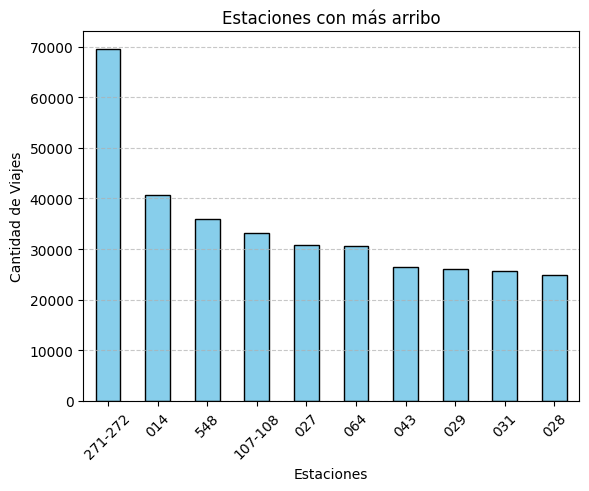

In [51]:
top_10_arribo.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Estaciones con más arribo')
plt.xlabel('Estaciones')
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

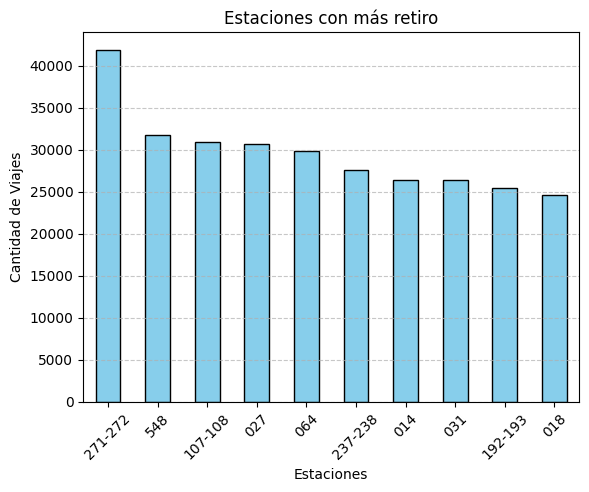

In [55]:
top_10_retiro.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Estaciones con más retiro')
plt.xlabel('Estaciones')
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()